In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import math
import warnings
import requests
from io import StringIO
# load CSV file from URL
url = "https://gist.githubusercontent.com/tmramalho/51733432c88e2b834dbd70353849f887/raw/676636d9e8512963005a318cb9b98060feadb641/data.csv"

# download CSV file
try:
    response = requests.get(url)
    response.raise_for_status()
    csv_data = StringIO(response.text)
    df = pd.read_csv(csv_data)
    print("CSV cuccess loaded")
    # print(df.head())  #check data
except requests.exceptions.RequestException as e:
    raise Exception(f"Failed to download or process CSV file: {e}")
# df = pd.read_csv('data.csv')
df.replace('-', np.nan, inplace=True)

# Round the time t to two decimal places to solve the floating point precision problem
df['t'] = df['t'].round(2)

# Remove duplicate time steps and keep the first occurrence
df = df.drop_duplicates(subset=['t'], keep='first').reset_index(drop=True)

t_full = np.arange(0.00, 20.01, 0.01)  #  t=20.00
df_full = pd.DataFrame({'t': t_full})

df = pd.merge(df_full, df, on='t', how='left')

# interpolate
df['x'] = df['x'].interpolate(method='linear')
df['y'] = df['y'].interpolate(method='linear')

# fill na with 0
df['x'].fillna(0, inplace=True)
df['y'].fillna(0, inplace=True)

# sort
df.sort_values('t', inplace=True)
df.reset_index(drop=True, inplace=True)

assert df.isnull().sum().sum() == 0, "There are still missing values ​​in the data!"

df['t_scaled'] = df['t'] / 100.0  

scaler_xy = StandardScaler()
df[['x_scaled', 'y_scaled']] = scaler_xy.fit_transform(df[['x', 'y']])

data = df[['t_scaled', 'x_scaled', 'y_scaled']].values  # shape: (2001, 3)


CSV cuccess loaded


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length, pred_length=10):
        """
        data: numpy array, shape (N, 3) contains [t_scaled, x_scaled, y_scaled]
        seq_length: input sequence length
        pred_length: predicted sequence length (default is 10)
        """
        self.seq_length = seq_length
        self.pred_length = pred_length
        self.data = data
        self.X = []
        self.Y = []
        N = len(data)
        for i in range(N - seq_length - pred_length + 1):
            self.X.append(data[i:i+seq_length, :])  # shape: (seq_length, 3)
            self.Y.append(data[i+seq_length:i+seq_length+pred_length, 1:3].flatten())  # shape: (pred_length*2,)
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.Y[idx], dtype=torch.float32)


In [12]:
# Define sequence length and prediction length
SEQ_LENGTH = 100   
PRED_LENGTH = 10   

dataset = TimeSeriesDataset(data, SEQ_LENGTH, PRED_LENGTH)

print(f"Total samples in dataset: {len(dataset)}")  # 1891

# Divide training set and validation set (80% training, 20% validation）
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")  
# 应输出: Training samples: 1512, Validation samples: 379


Total samples in dataset: 1893
Training samples: 1514, Validation samples: 379


In [13]:
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [14]:
import torch.nn as nn
import torch.optim as optim

class LSTMModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, num_layers=3, output_size=20, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM 
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))  # out: (batch, seq_length, hidden_size)

        out = out[:, -1, :]  # (batch, hidden_size)

        out = self.fc(out)  # (batch, output_size)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [15]:
import numpy as np

# training parameters
NUM_EPOCHS = 1000
best_val_loss = np.inf
patience = 100  # Increase patience
counter = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    train_losses = []
    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)  # shape: (batch, pred_length*2)
    
        optimizer.zero_grad()
        outputs = model(X_batch)  # Output shape: (batch, pred_length*2)
    
        loss = criterion(outputs, Y_batch)  # MSE loss
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    avg_train_loss = np.mean(train_losses)
    
    # verify
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, Y_batch in val_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            val_losses.append(loss.item())
    avg_val_loss = np.mean(val_losses)
    
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_lstm_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

print("Training complete")


Epoch [1/1000], Train Loss: 0.977773, Val Loss: 0.962519
Epoch [2/1000], Train Loss: 0.892950, Val Loss: 0.932528
Epoch [3/1000], Train Loss: 0.849996, Val Loss: 0.895353
Epoch [4/1000], Train Loss: 0.838537, Val Loss: 0.899555
Epoch [5/1000], Train Loss: 0.835181, Val Loss: 0.905343
Epoch [6/1000], Train Loss: 0.835353, Val Loss: 0.894017
Epoch [7/1000], Train Loss: 0.832753, Val Loss: 0.899416
Epoch [8/1000], Train Loss: 0.840400, Val Loss: 0.898340
Epoch [9/1000], Train Loss: 0.832274, Val Loss: 0.891385
Epoch [10/1000], Train Loss: 0.828653, Val Loss: 0.893403
Epoch [11/1000], Train Loss: 0.831781, Val Loss: 0.892338
Epoch [12/1000], Train Loss: 0.823653, Val Loss: 0.886470
Epoch [13/1000], Train Loss: 0.825342, Val Loss: 0.893238
Epoch [14/1000], Train Loss: 0.827815, Val Loss: 0.887845
Epoch [15/1000], Train Loss: 0.820562, Val Loss: 0.880552
Epoch [16/1000], Train Loss: 0.812954, Val Loss: 0.886861
Epoch [17/1000], Train Loss: 0.814678, Val Loss: 0.881318
Epoch [18/1000], Train 

In [7]:
# Load the best model
model.load_state_dict(torch.load('best_lstm_model.pth'))
model.eval()


/tmp/ipykernel_2966475/984441287.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_lstm_model.pth'))


LSTMModel(
  (lstm): LSTM(3, 128, num_layers=3, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=20, bias=True)
)

In [8]:
sequence = df.iloc[-SEQ_LENGTH:][['t_scaled', 'x_scaled', 'y_scaled']].values  # shape: (seq_length, 3)
sequence = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)  # shape: (1, seq_length, 3)

# Define the number of prediction steps
future_steps = int((100 - 20) / 0.01)  # 从 t=20 到 t=100，每步0.01，共8000步
batch_predict_steps = 10  

predictions = []

for step in range(0, future_steps, batch_predict_steps):
    current_batch_steps = min(batch_predict_steps, future_steps - step)
    
    with torch.no_grad():
        pred = model(sequence)  # (1, pred_length*2)
        pred = pred.cpu().numpy().flatten()[:current_batch_steps*2]  # Get the prediction for the current batch step number
        predictions.extend(pred)
    
    last_t_scaled = sequence[0, -1, 0].item()
    new_t_scaled = last_t_scaled + (current_batch_steps * 0.01) / 100.0  
    new_t_scaled = min(new_t_scaled, 1.0)  
    
    for i in range(current_batch_steps):
        pred_x_scaled = pred[2*i]
        pred_y_scaled = pred[2*i + 1]
        
        new_entry = [new_t_scaled + (i+1)*0.01/100.0, pred_x_scaled, pred_y_scaled]
        new_entry = torch.tensor(new_entry, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,3)
        
        sequence = torch.cat((sequence[:, 1:, :], new_entry), dim=1)


predictions = np.array(predictions).reshape(-1, 2)  # shape: (future_steps, 2)

predictions_df = pd.DataFrame(predictions, columns=['x_scaled', 'y_scaled'])
predictions_df[['x', 'y']] = scaler_xy.inverse_transform(predictions_df[['x_scaled', 'y_scaled']])

last_t = df['t'].iloc[-1]  # 20.00
future_t = np.linspace(last_t + 0.01, last_t + 0.01 * future_steps, future_steps)
future_t = np.clip(future_t, None, 100.0)  

predictions_df['t'] = future_t


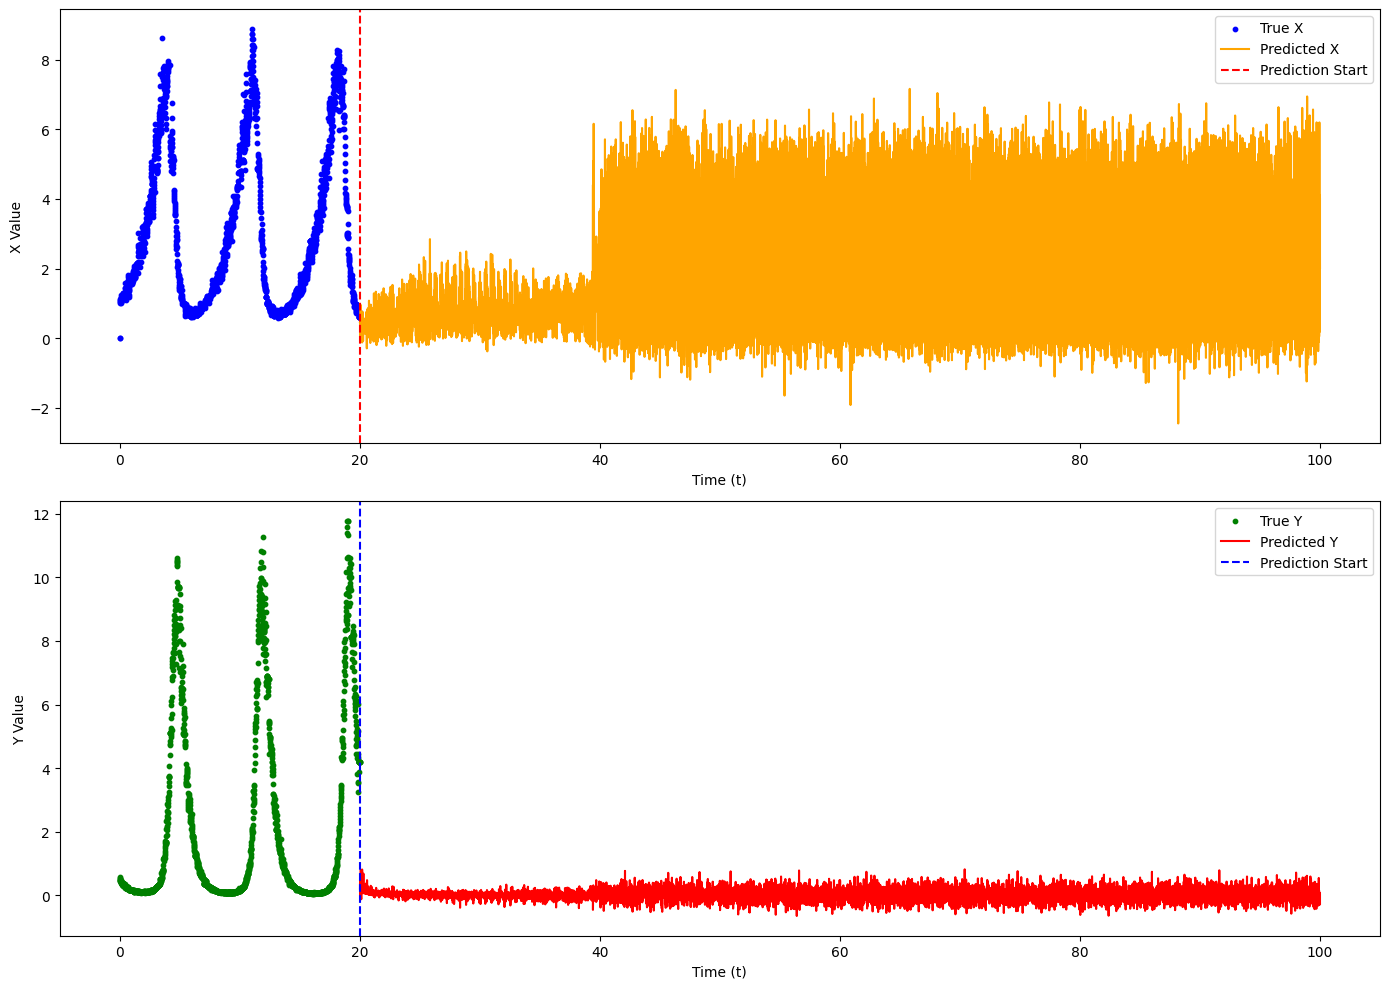

In [ ]:
import matplotlib.pyplot as plt

# raw data
df_original = pd.read_csv('data.csv')
df_original.replace('-', np.nan, inplace=True)
df_original['t'] = df_original['t'].round(2)
df_original = df_original.drop_duplicates(subset=['t'], keep='first').reset_index(drop=True)
df_original['x'] = df_original['x'].astype(float)
df_original['y'] = df_original['y'].astype(float)

# Generate full time steps and interpolate (consistent with preprocessing step)
t_full = np.arange(0.00, 20.01, 0.01)
df_full_original = pd.DataFrame({'t': t_full})
df_original = pd.merge(df_full_original, df_original, on='t', how='left')
df_original['x'] = df_original['x'].interpolate(method='linear').fillna(0)
df_original['y'] = df_original['y'].interpolate(method='linear').fillna(0)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.scatter(df_original['t'], df_original['x'], label='True X', s=10, color='blue')
plt.plot(predictions_df['t'], predictions_df['x'], label='Predicted X', color='orange')
plt.axvline(x=20, color='red', linestyle='--', label='Prediction Start')
plt.xlabel('Time (t)')
plt.ylabel('X Value')
plt.legend()

plt.subplot(2, 1, 2)
plt.scatter(df_original['t'], df_original['y'], label='True Y', s=10, color='green')
plt.plot(predictions_df['t'], predictions_df['y'], label='Predicted Y', color='red')
plt.axvline(x=20, color='blue', linestyle='--', label='Prediction Start')
plt.xlabel('Time (t)')
plt.ylabel('Y Value')
plt.legend()

plt.tight_layout()
plt.show()
